##import the dependencies

In [2]:
import numpy as np # useful for make np arrays
import pandas as pd #useful for make Data Frames
import matplotlib.pyplot as plt #useful for make Visualization
import seaborn as sns #useful for plotting
import sklearn.datasets #useful for make datasets
from sklearn.model_selection import train_test_split # to split the data for training and testing
from xgboost import XGBRegressor
from sklearn import metrics # useful for know the accuracy of the model
from sklearn.datasets import fetch_california_housing

##import the Boston House Price Data

In [3]:
House_price_Data=fetch_california_housing()

In [4]:
House_price_Data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

##Loading the data set to pandas

In [5]:
House_Price_DF=pd.DataFrame(House_price_Data.data,columns=House_price_Data.feature_names)

##Print the frist 5 Rows

In [6]:
House_Price_DF.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [7]:
#add the target Column
House_Price_DF["Price"]=House_price_Data.target

In [8]:
#check the number of rows and columns
House_Price_DF.shape
#check for missing values
House_Price_DF.isnull().sum().sort_values(ascending=False)

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Price,0


#statical mesaures for data set

In [9]:
House_Price_DF.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [10]:
House_Price_DF.info()
# House_Price_DF.infer_objects()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


##Correlations and HeatMap to understand it

<Axes: >

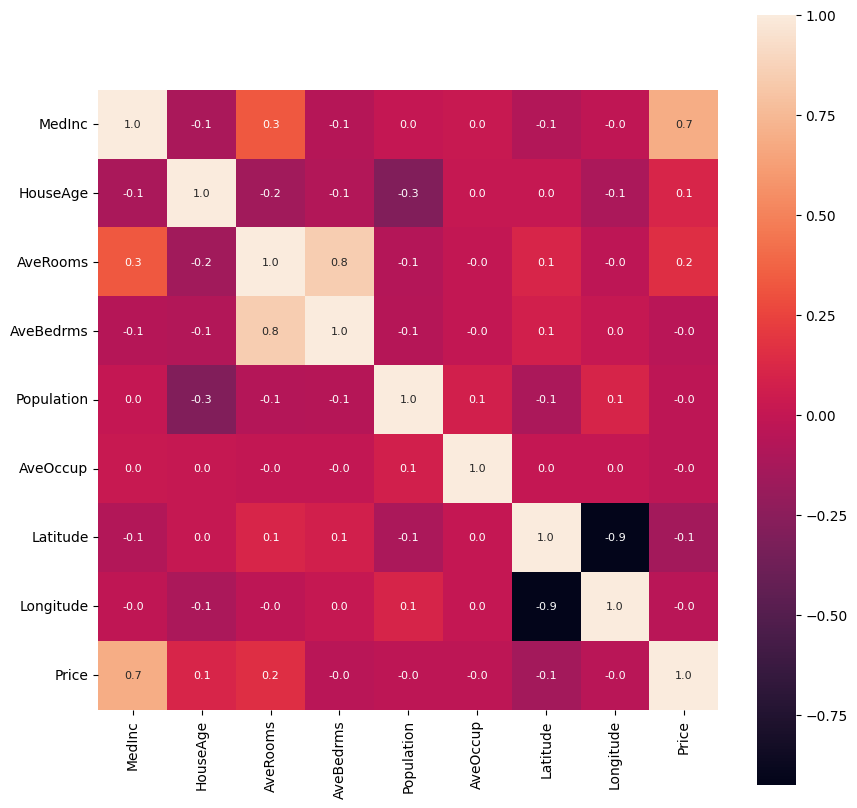

In [11]:
Correlations=House_Price_DF.corr()
plt.figure(figsize=(10,10))

sns.heatmap(Correlations,annot=True,cbar=True,square=True,fmt=".1f",annot_kws={"size":8})

##Spliting The data and Target

In [14]:
X=House_Price_DF.drop(columns="Price",axis=1)
Y=House_Price_DF["Price"]

In [21]:
print(X)
print(Y)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

##Split Data to train and test

In [23]:
X_train,X_Test,Y_Train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

##XGBoost Regressor

In [30]:
XGmodel=XGBRegressor()
XGmodel.fit(X_train,Y_Train)
prediction=XGmodel.predict(X_Test)
prediction=pd.DataFrame(prediction)

In [31]:
print(prediction)

             0
0     0.594452
1     0.784119
2     5.198116
3     2.439808
4     2.427432
...        ...
4123  2.402855
4124  1.927941
4125  5.058281
4126  0.761060
4127  1.837590

[4128 rows x 1 columns]


In [37]:
MAS=metrics.mean_absolute_error(Y_test,prediction)
print("Mean absolute Error:",MAS)
R_square_Error=metrics.r2_score(Y_test,prediction)
print("R Square Error:",R_square_Error)

Mean absolute Error: 0.30957335413783094
R Square Error: 0.8301370561019205


In [38]:
#Visialization between the actual prices and predictied prices

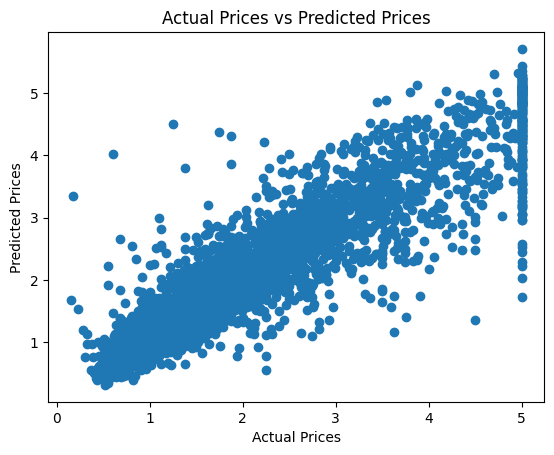

In [39]:
plt.scatter(Y_test,prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show()